In [1]:
import pickle

# Specify the path to your pickle file
file_path = r'/home/ddew0188/PHS/pysmambaSpo2/rPPG-Toolbox/runs/exp2/NBHR_SizeW128_SizeH128_ClipLength60_DataTypeDiffNormalized_DataAugNone_LabelTypeStandardized_Crop_faceTrue_BackendYOLOv5_Large_boxTrue_Large_size1.5_Dyamic_DetFalse_det_len32_Median_face_boxTrue/saved_test_outputs/NBHR_PhysMamba_Epoch35_NBHR_outputs.pickle'
# Open the file in binary read mode and load the object
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Now `data` contains the deserialized object from the pickle file
print(type(data))


<class 'dict'>


In [5]:
for key in data.keys():
    print(f"{key}: {type(data[key])}")


predictions: <class 'tuple'>
labels: <class 'tuple'>
label_type: <class 'str'>
fs: <class 'int'>


In [ ]:
pred_dict = data["predictions"][1]
label_dict = data["labels"][1]

# Flatten and round predictions
pred_values = []
label_values = []
for subj_id, chunk_map in pred_dict.items():
    for chunk_idx, pred_tensor in chunk_map.items():
        # pred_tensor is e.g. torch.tensor(92.4) or similar
        pred_values.append(round(float(pred_tensor)))

        lab_tensor = label_dict[subj_id][chunk_idx]
        label_values.append(round(float(lab_tensor)))

print(pred_values)
print(label_values)


[97, 96, 97, 96, 97, 97, 97, 97, 97, 97, 97, 97, 97, 96, 96, 96, 96, 96, 97, 97, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 99, 98, 97, 96, 96, 96, 96, 97, 96, 96, 97, 97, 96, 95, 95, 96, 95, 96, 95, 95, 96, 96, 96, 95, 91, 90, 91, 91, 90, 91, 91, 91, 90, 90, 90, 91, 97, 96, 97, 96, 97, 96, 96, 97, 97, 97, 96, 96, 96, 96, 97, 96, 96, 96, 96, 96, 97, 96, 92, 91, 92, 92, 92, 92, 91, 92, 92, 92, 92, 98, 98, 98, 98, 98, 98, 98, 98, 98, 97, 96, 96, 96, 95, 92, 93, 92, 92, 92, 92, 92, 92, 95, 95, 95, 96, 95, 95, 95, 95, 95, 96, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 94, 98, 98, 98, 98, 98, 97, 98, 98, 96, 96, 97, 98, 98, 97, 98, 98, 98, 98, 98, 97, 97, 97, 97, 97, 98, 98, 98, 98, 98, 97, 98, 98, 98, 98, 98, 98, 97, 98, 98, 97, 98, 97, 98, 98, 97, 98, 98, 98, 98, 98, 98, 98, 97, 97, 97, 98, 97, 97, 98, 97, 97, 98, 98, 97, 97, 98, 98, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 96, 97, 96, 97, 97, 96, 96, 95, 96, 96, 96, 96, 96, 96, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97,

## Analysis

In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error


# Compute RMSE
rmse = np.sqrt(mean_squared_error(label_values, pred_values))

print("Test RMSE:", rmse)


Test RMSE: 2.8744771478384554


In [10]:
pred_dict = data["predictions"][0]
label_dict = data["labels"][0]

# Flatten and round predictions
pred_values = []
label_values = []
for subj_id, chunk_map in pred_dict.items():
    for chunk_idx, pred_tensor in chunk_map.items():
        # pred_tensor is e.g. torch.tensor(92.4) or similar
        pred_values.append(pred_tensor)

        lab_tensor = label_dict[subj_id][chunk_idx]
        label_values.append(lab_tensor)

print(pred_values)
print(label_values)

[tensor([ 0.2590,  0.1286,  0.0176, -0.1249, -0.2121, -0.4126, -0.5445, -0.5077,
        -0.4112, -0.1379,  0.0660,  0.2876,  0.3821,  0.4270,  0.3683,  0.1931,
        -0.0379, -0.3449, -0.5114, -0.6445, -0.6317, -0.4895, -0.3035, -0.0503,
         0.1077,  0.3402,  0.4787,  0.4552,  0.3899,  0.1702, -0.1272, -0.3932,
        -0.4825, -0.5629, -0.5801, -0.4815, -0.3748, -0.1260,  0.0893,  0.3169,
         0.3308,  0.3422,  0.2508,  0.0618, -0.0714, -0.2586, -0.4031, -0.4266,
        -0.3990, -0.2668, -0.1616, -0.0352,  0.0009,  0.1423,  0.1398,  0.2730,
         0.2124,  0.0521,  0.0539, -0.0158]), tensor([ 0.0575, -0.0836, -0.1964, -0.2628, -0.1741,  0.0062,  0.0799,  0.1400,
         0.2448,  0.3172,  0.2635,  0.1272, -0.0354, -0.3205, -0.4847, -0.5548,
        -0.5145, -0.3062, -0.1317,  0.0526,  0.1515,  0.2568,  0.2813,  0.1949,
         0.0524, -0.2456, -0.4340, -0.5516, -0.5316, -0.4021, -0.2761, -0.1324,
         0.0057,  0.2229,  0.3603,  0.4122,  0.3543,  0.1976, -0.0555, -0

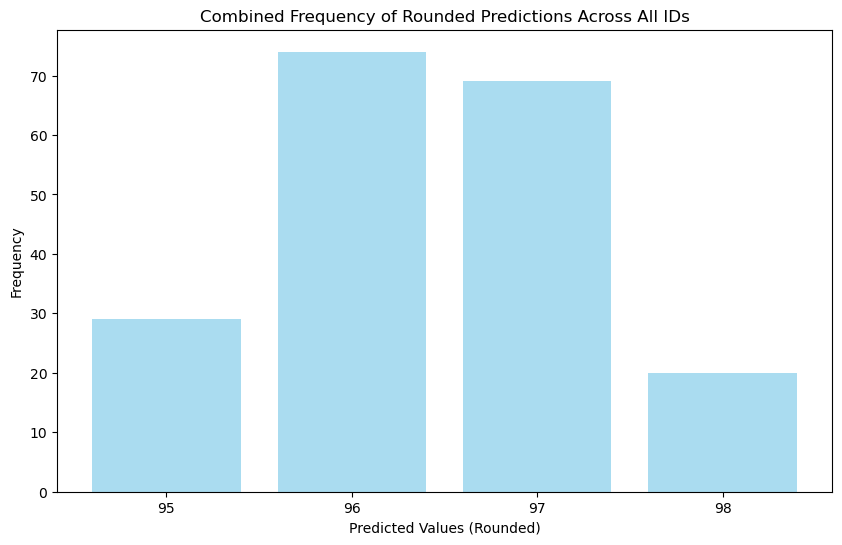

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data - replace this with your actual predictions dictionary
predictions = data["predictions"]

# Initialize a dictionary to store summed frequencies across all IDs
frequency_counts = {}

# Aggregate rounded predictions across all IDs
for preds in predictions.values():
    for pred in preds.values():
        rounded_pred = round(float(pred))
        if rounded_pred in frequency_counts:
            frequency_counts[rounded_pred] += 1
        else:
            frequency_counts[rounded_pred] = 1

# Convert frequency_counts to lists for plotting
unique_values = list(frequency_counts.keys())
counts = list(frequency_counts.values())

# Plot the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(unique_values, counts, color='skyblue', alpha=0.7)

# Customize the plot
ax.set_xlabel('Predicted Values (Rounded)')
ax.set_ylabel('Frequency')
ax.set_title('Combined Frequency of Rounded Predictions Across All IDs')

# Set x-axis ticks if you know the range of values
plt.xticks(range(min(unique_values), max(unique_values) + 1))  # Modify range as per your data

# Show the plot
plt.show()


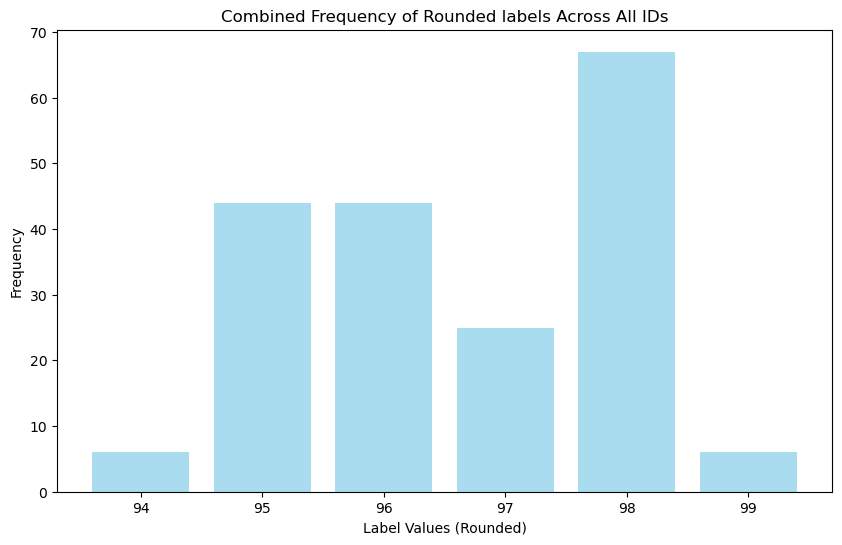

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data - label dictionary
predictions = data["labels"]

# Initialize a dictionary to store summed frequencies across all IDs
frequency_counts = {}

# Aggregate rounded predictions across all IDs
for preds in predictions.values():
    for pred in preds.values():
        rounded_pred = round(float(pred))
        if rounded_pred in frequency_counts:
            frequency_counts[rounded_pred] += 1
        else:
            frequency_counts[rounded_pred] = 1

# Convert frequency_counts to lists for plotting
unique_values = list(frequency_counts.keys())
counts = list(frequency_counts.values())

# Plot the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(unique_values, counts, color='skyblue', alpha=0.7)

# Customize the plot
ax.set_xlabel('Label Values (Rounded)')
ax.set_ylabel('Frequency')
ax.set_title('Combined Frequency of Rounded labels Across All IDs')

# Set x-axis ticks if you know the range of values
plt.xticks(range(min(unique_values), max(unique_values) + 1))  # Modify range as per your data

# Show the plot
plt.show()

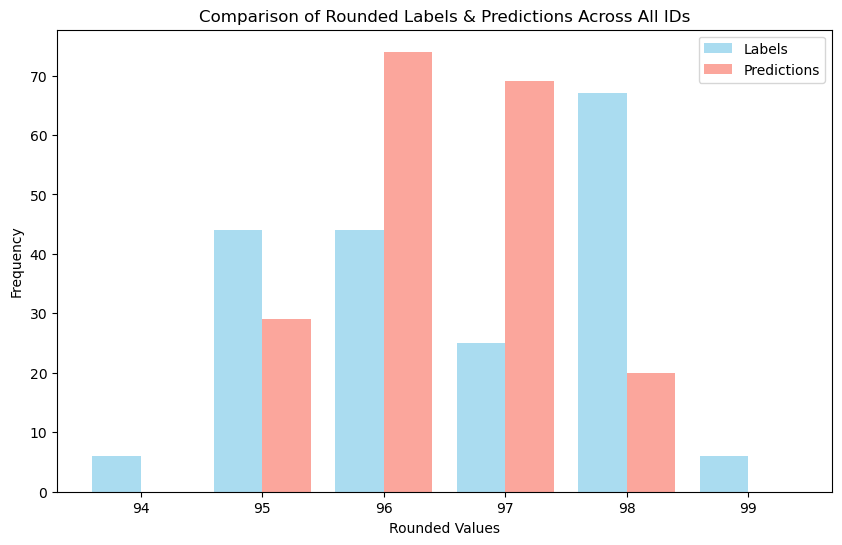

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
labels = data["labels"]
predictions = data["predictions"]

# Initialize dictionaries to store summed frequencies across all IDs
label_counts = {}
prediction_counts = {}

# Aggregate rounded labels
for preds in labels.values():
    for pred in preds.values():
        rounded_label = round(float(pred))
        label_counts[rounded_label] = label_counts.get(rounded_label, 0) + 1

# Aggregate rounded predictions
for preds in predictions.values():
    for pred in preds.values():
        rounded_pred = round(float(pred))
        prediction_counts[rounded_pred] = prediction_counts.get(rounded_pred, 0) + 1

# Get unique values (combined from both dictionaries)
unique_values = sorted(set(label_counts.keys()).union(set(prediction_counts.keys())))

# Create counts lists aligned with unique values
label_frequencies = [label_counts.get(val, 0) for val in unique_values]
prediction_frequencies = [prediction_counts.get(val, 0) for val in unique_values]

# Set bar width for side-by-side bars
bar_width = 0.4

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot labels and predictions side by side
ax.bar(np.array(unique_values) - bar_width/2, label_frequencies, width=bar_width, label="Labels", color='skyblue', alpha=0.7)
ax.bar(np.array(unique_values) + bar_width/2, prediction_frequencies, width=bar_width, label="Predictions", color='salmon', alpha=0.7)

# Customize the plot
ax.set_xlabel('Rounded Values')
ax.set_ylabel('Frequency')
ax.set_title('Comparison of Rounded Labels & Predictions Across All IDs')
ax.set_xticks(unique_values)  # Set x-axis ticks to match unique values
ax.legend()

# Show the plot
plt.show()


## Confusion Matrix

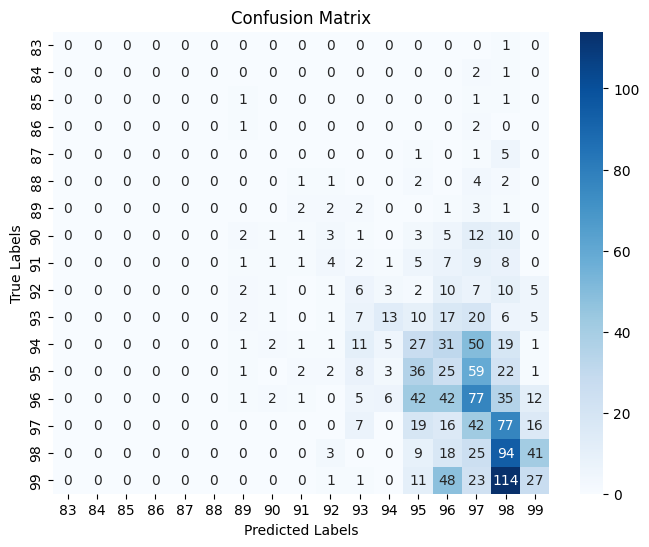

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Sample predictions and labels data - replace with your actual data
predictions = data["predictions"][1]
labels = data["labels"][1]

# Step 1: Flatten and round predictions and labels
pred_values = []
label_values = []

for key in predictions:
    for sub_key in predictions[key]:
        pred_values.append(round(predictions[key][sub_key].item()))
        label_values.append(round(labels[key][sub_key].item()))

# print(pred_values)
# print(label_values)
# Step 2: Calculate confusion matrix
cm = confusion_matrix(label_values, pred_values)

# Step 3: Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(label_values), yticklabels=np.unique(label_values))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()